In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf

In [2]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# Droping rows with misiing age and embarked values
df.dropna(subset=['age', 'embarked'], inplace=True)

In [4]:
# Converting the categorical varibale to dummy variables
df = pd.get_dummies(df, columns=['sex', 'embarked', 'class', 'who', 'deck'], drop_first=True)

In [5]:
# Selecting features and target
X = df.drop(columns=['survived', 'alive', 'embark_town', 'adult_male', 'alone'])
y = df['survived']

In [6]:
# Spliting the dataset
X_train,X_test, y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [7]:
# Standardizing the data
scaler= StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
# Building the model

input_layer = tf.keras.layers.Dense(
    10,
    activation='relu',
    input_shape=(X_train.shape[1],)
)

output_layer = tf.keras.layers.Dense(
    1,
    activation='sigmoid'
)

model = tf.keras.models.Sequential([
    input_layer,
    output_layer
])


C:\Users\2005a\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [10]:
# train the model
model.fit(X_train,y_train, epochs=100, batch_size=32, verbose=1)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3427 - loss: 0.8653
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3849 - loss: 0.7831 
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5782 - loss: 0.7180 
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6081 - loss: 0.6636 
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6626 - loss: 0.6180 
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7153 - loss: 0.5833
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7329 - loss: 0.5547  
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7487 - loss: 0.5309 
Epoch 9/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7540 - loss: 0.5118 
Epoch 10/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7627 - loss: 0.4958  
Epoch 11/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7698 - loss: 0.4828 
Epoch 12/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10m

In [11]:
# Evaluating the model
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Accuracy : {accuracy}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7902 - loss: 0.5001 
Test Accuracy : 0.7902097702026367


In [12]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8440 - loss: 0.3588 - val_accuracy: 0.8509 - val_loss: 0.3754
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8462 - loss: 0.3581 - val_accuracy: 0.8333 - val_loss: 0.3784
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8462 - loss: 0.3576 - val_accuracy: 0.8333 - val_loss: 0.3807
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8462 - loss: 0.3569 - val_accuracy: 0.8333 - val_loss: 0.3829
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8505 - loss: 0.3562 - val_accuracy: 0.8333 - val_loss: 0.3861
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8462 - loss: 0.3559 - val_accuracy: 0.8333 - val_loss: 0.3871
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8484 - loss: 0.3554 - val_accuracy: 0.8333 - val_loss: 0.3890
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8484 - loss: 0.3552 - val_accuracy: 0.8333 - v

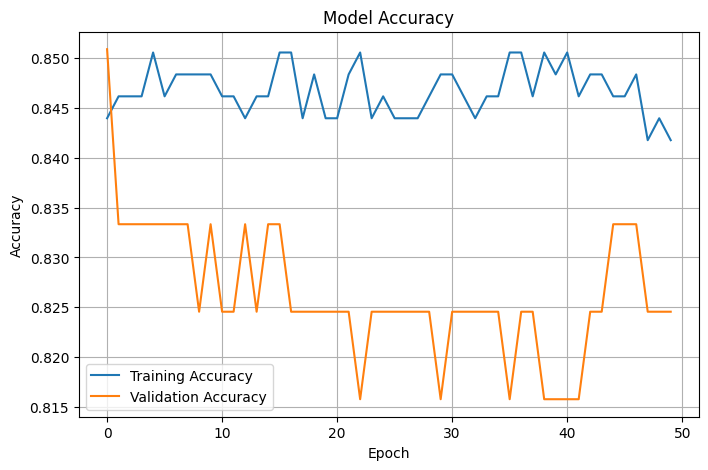

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

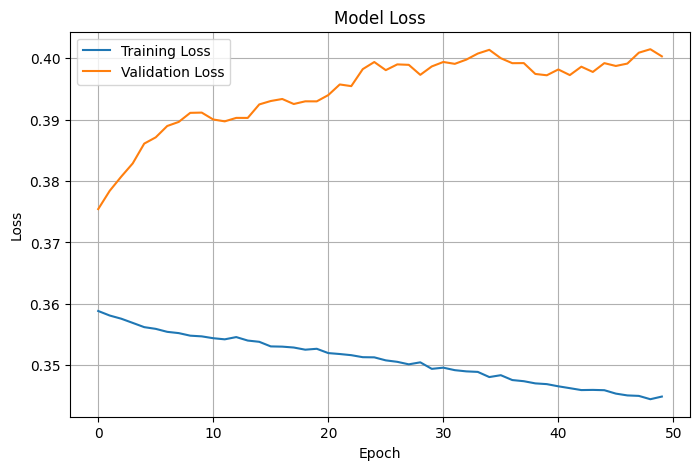

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()